In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
house = pd.read_csv("house.csv")

In [ ]:
house

,Area,Bedrooms,Bathrooms,Material,Locality,Price
0,1790,2,2,Concrete,Riverside,114300
1,2030,4,2,Concrete,Riverside,114200
2,1740,3,2,Concrete,Riverside,114800
3,1980,3,2,Concrete,Riverside,94700
4,2130,3,3,Concrete,Riverside,119800
...,...,...,...,...,...,...
123,1900,3,3,Masonry,Riverside,119700
124,2160,4,3,Masonry,Riverside,147900
125,2070,2,2,Concrete,Polar Grove,113500
126,2020,3,3,Concrete,Summit View,149900


In [ ]:
X = house[['Area']]

In [ ]:
Y = house['Price']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25, random_state=42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

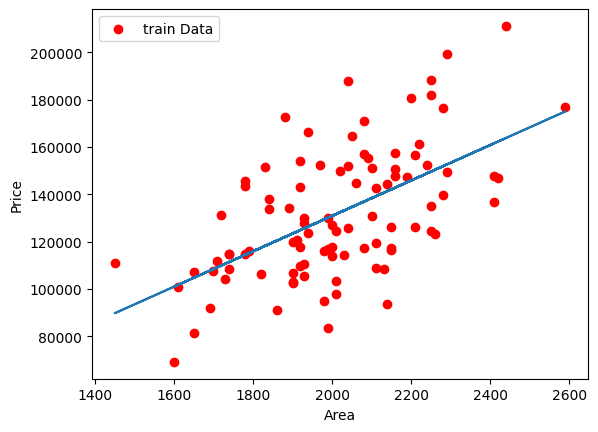

In [ ]:
plt.scatter(X_train,Y_train, color = 'red', label = "train Data")
plt.plot(X_train,model.predict(X_train))
plt.legend()
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [ ]:
Y_train_pred = model.predict(X_train)

In [ ]:
# The first argument should always be the actual values, and the second should be the predicted values.
r2_score(Y_train,Y_train_pred)

0.32875680616329306

In [ ]:
print("Train RMSE:", np.sqrt(mean_squared_error(Y_train, Y_train_pred)))


Train RMSE: 22362.946915128254


In [ ]:
Y_test_pred = model.predict(X_test)



In [ ]:
print(r2_score(Y_test,Y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(Y_test, Y_test_pred)))


0.19464215306124688
Test RMSE: 22219.314632146063


In [ ]:
# create dummy variable for categorical variable

In [ ]:
print(house.columns.tolist())

['Area', 'Bedrooms', 'Bathrooms', 'Material', 'Locality', 'Price']


In [ ]:
house = pd.get_dummies(house, columns=['Material','Locality'], drop_first=True,dtype=int)

In [ ]:
house

,Area,Bedrooms,Bathrooms,Price,Material_Masonry,Locality_Riverside,Locality_Summit View
0,1790,2,2,114300,0,1,0
1,2030,4,2,114200,0,1,0
2,1740,3,2,114800,0,1,0
3,1980,3,2,94700,0,1,0
4,2130,3,3,119800,0,1,0
...,...,...,...,...,...,...,...
123,1900,3,3,119700,1,1,0
124,2160,4,3,147900,1,1,0
125,2070,2,2,113500,0,0,0
126,2020,3,3,149900,0,0,1


In [ ]:
X = house.drop('Price', axis=1)

In [ ]:
Y = house['Price']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.25,random_state=42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
Y_train_pred = model.predict(X_train)


In [ ]:
r2_score(Y_train,Y_train_pred)

0.8078940847741882

In [ ]:
print(np.sqrt(mean_squared_error(Y_train,Y_train_pred)))

11963.533061848673


In [ ]:
Y_test_pred = model.predict(X_test)


In [ ]:
r2_score(Y_test,Y_test_pred)

0.7770349831900601

In [ ]:
print(np.sqrt(mean_squared_error(Y_test,Y_test_pred)))

11691.078464442837


"The model does not appear to be overfitting because the training R² is 0.80 and the testing R² is 0.77. The small difference of 3% indicates that the model generalizes well to unseen data while maintaining good predictive performance."

In [ ]:
import pickle
import json

# Save Risk Model
with open('house_model.pkl', 'wb') as f:
    pickle.dump(model, f)